[ DATA ]
    avg_word_length  sender_reputation  num_links  offer_score  target
0               4.5               0.91          2         0.85       1
1               3.6               0.42          0         0.10       0
2               4.8               0.88          1         0.70       1
3               3.9               0.51          0         0.05       0
4               5.1               0.92          3         0.95       1
5               3.5               0.38          0         0.00       0
6               4.7               0.89          2         0.80       1
7               3.7               0.45          0         0.10       0
8               4.9               0.93          2         0.90       1
9               3.8               0.40          0         0.00       0
10              5.0               0.90          1         0.85       1
11              3.6               0.41          0         0.05       0
12              4.6               0.87          1         0.75      

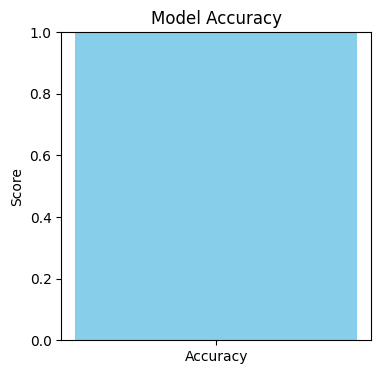

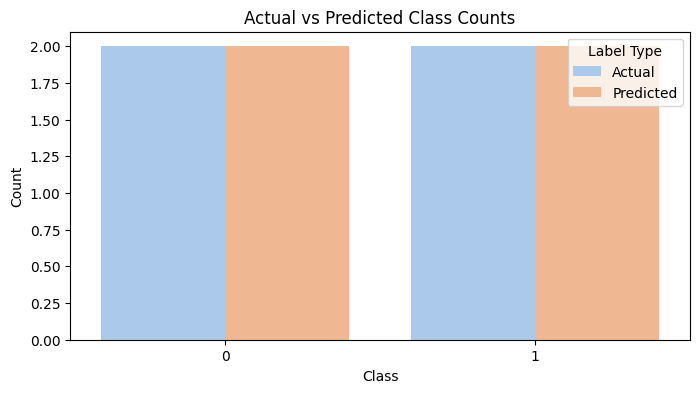

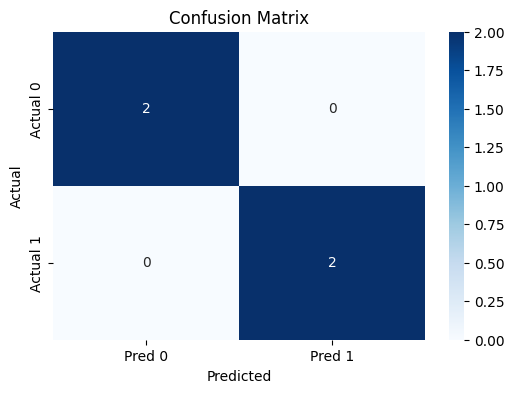

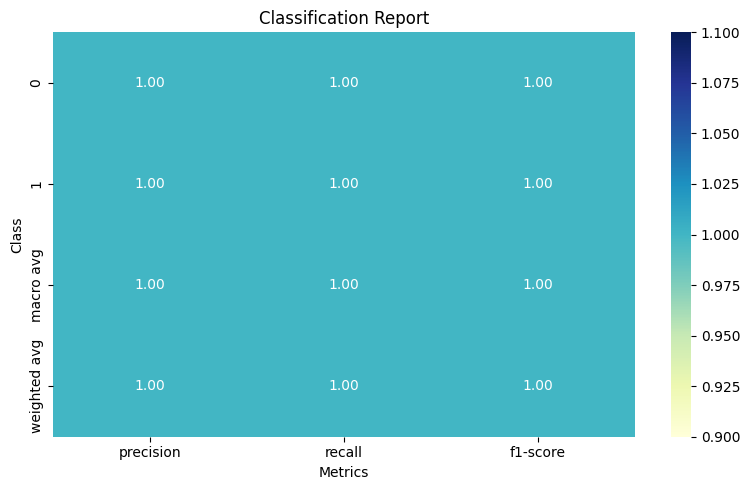

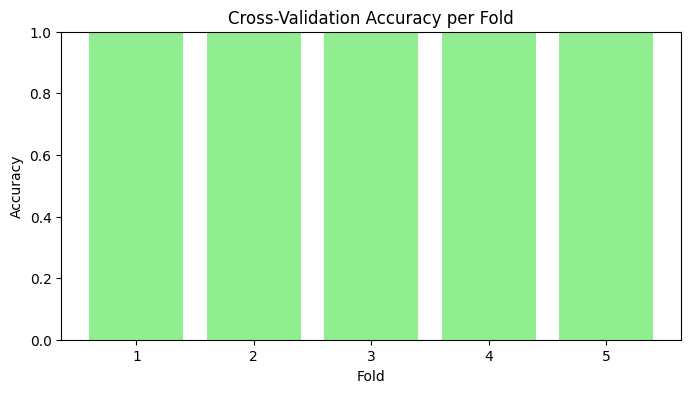

In [2]:
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC

# load & prepare data
data = pd.read_csv('../../CSV/spam_email_svm.csv')
X = data.drop(columns='target')
y = data['target']

print("[ DATA ]")
print(data)

# split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# train model
model = SVC(probability=True, kernel='linear')  # or 'rbf', 'poly', etc.
model.fit(X_train, y_train)

# test model by making predictions
# Get predicted probabilities
probs = model.predict_proba(X_test)[:, 1]

# Adjust threshold to reduce false negatives or false positives
threshold = 0.5 # tweak this to balance FP and FN
predictions = (probs > threshold).astype(int)


# evaluate model
accuracy = accuracy_score(y_test, predictions)

# save model
joblib.dump(model, 'modelsspam_email_classifier[SVM].joblib')

# 1. Accuracy - Bar Plot
print("[ ACCURACY ]")
plt.figure(figsize=(4, 4))
plt.bar(["Accuracy"], [accuracy], color='skyblue')
plt.ylim(0, 1)
plt.title("Model Accuracy")
plt.ylabel("Score")
plt.show()


# 2. Actual vs Predicted - Bar Chart
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

plt.figure(figsize=(8, 4))
sns.countplot(
    x='value', hue='Type',
    data=pd.melt(results_df, value_vars=['Actual', 'Predicted'], var_name='Type'),
    palette='pastel'
)
plt.title("Actual vs Predicted Class Counts")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend(title='Label Type')
plt.show()

# 3. Confusion Matrix - Heatmap
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 4. Precision, Recall, F1 Score - Heatmap
report = classification_report(y_test, predictions, output_dict=True)

# Convert to DataFrame (remove 'accuracy' to keep it 2D for heatmap)
report_df = pd.DataFrame(report).drop(columns=['accuracy'])
plt.figure(figsize=(8, 5))
sns.heatmap(report_df.iloc[:3, :].T, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report")
plt.ylabel("Class")
plt.xlabel("Metrics")
plt.tight_layout()
plt.show()

# 5. Cross-Validation Scores - Bar Plot
scores = cross_val_score(model, X, y, cv=5)
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), scores, color='lightgreen')
plt.ylim(0, 1)
plt.title("Cross-Validation Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(range(1, 6))
plt.show()